# Exploratory Data Analysis (EDA)

This notebook provides a reusable starting point for exploratory data analysis in this project.

**Default dataset:** `../data/clean/EnrollmentsAUS_category_with_numeric_key.csv`

> If you want to explore a different file, update `dataset_path` in the next code cell.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

# Update this path if you want to analyze a different dataset
dataset_path = Path("../data/clean/EnrollmentsAUS_category_with_numeric_key.csv")

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path.resolve()}")

# Try a standard CSV load first
try:
    df = pd.read_csv(dataset_path)
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding="latin-1")

print(f"Loaded {dataset_path.name}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
df.head()

Loaded EnrollmentsAUS_category_with_numeric_key.csv
Rows: 12 | Columns: 11


,Category,2016,2017,2018,2019,2020,2021,2022,2023,2024,CategoryKey
0,Natural & Physical Science,119102,124209,129609,134334,136733,139629,134424,132406,134511,1
1,Information Technology,66355,80090,99986,116623,120916,116296,119278,143253,164464,2
2,Engineering & Related Tech,111060,115231,119909,121980,118229,112931,109812,115197,122954,3
3,Architecture & Building,32074,35604,39459,42370,43478,43773,42327,42174,40942,4
4,Environment & Related,18537,18260,18055,18747,21916,20776,19476,19284,19376,5


## 1. Inspect Data Structure

Review column names, data types, shape, and general dataset information.

In [7]:
print("Column names:")
print(df.columns.tolist())

year_cols = [col for col in df.columns if str(col).isdigit()]
id_cols = [col for col in df.columns if col not in year_cols]

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\nDetected year columns: {year_cols}")
print(f"Identifier columns: {id_cols}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nShape: {df.shape}")
print("\nDataset info:")
df.info()

enrollment_long = df.melt(
    id_vars=id_cols,
    value_vars=year_cols,
    var_name="Year",
    value_name="Enrollments",
)
enrollment_long["Year"] = enrollment_long["Year"].astype(int)
enrollment_long["Enrollments"] = pd.to_numeric(enrollment_long["Enrollments"], errors="coerce")

if "Category" in enrollment_long.columns:
    enrollment_long_no_total = enrollment_long[enrollment_long["Category"] != "Total"].copy()
else:
    enrollment_long_no_total = enrollment_long.copy()

print("\nLong-format preview:")
display(enrollment_long.head())

Column names:
['Category', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'CategoryKey']

Detected year columns: ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Identifier columns: ['Category', 'CategoryKey']

Data types:


,dtype
Category,str
2016,int64
2017,int64
2018,int64
2019,int64
2020,int64
2021,int64
2022,int64
2023,int64
2024,int64



Shape: (12, 11)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Category     12 non-null     str  
 1   2016         12 non-null     int64
 2   2017         12 non-null     int64
 3   2018         12 non-null     int64
 4   2019         12 non-null     int64
 5   2020         12 non-null     int64
 6   2021         12 non-null     int64
 7   2022         12 non-null     int64
 8   2023         12 non-null     int64
 9   2024         12 non-null     int64
 10  CategoryKey  12 non-null     int64
dtypes: int64(10), str(1)
memory usage: 1.2 KB

Long-format preview:


,Category,CategoryKey,Year,Enrollments
0,Natural & Physical Science,1,2016,119102
1,Information Technology,2,2016,66355
2,Engineering & Related Tech,3,2016,111060
3,Architecture & Building,4,2016,32074
4,Environment & Related,5,2016,18537


## 2. Clean Missing Values and Duplicates

Check for null values and duplicate rows, then create a lightly cleaned copy of the dataset.

In [4]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
display(missing_summary.to_frame("missing_count") if not missing_summary.empty else pd.DataFrame({"message": ["No missing values found"]}))

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
print(f"Shape after dropping duplicates: {df_clean.shape}")

Missing values by column:


,message
0,No missing values found


Duplicate rows: 0
Shape after dropping duplicates: (12, 11)


## 3. Compute Summary Statistics

Generate descriptive statistics for both numeric and categorical columns.

In [8]:
df_clean_no_total = df_clean[df_clean["Category"] != "Total"].copy() if "Category" in df_clean.columns else df_clean.copy()

numeric_cols = year_cols + (["CategoryKey"] if "CategoryKey" in df_clean.columns else [])
categorical_cols = ["Category"] if "Category" in df_clean.columns else []

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

if year_cols:
    print("\nSummary statistics by year:")
    display(df_clean_no_total[year_cols].describe().T)

    year_totals = pd.DataFrame({
        "Total Enrollments": df_clean[year_cols].sum(),
        "Average per Category": df_clean_no_total[year_cols].mean(),
    })
    display(year_totals)
else:
    print("No year columns detected for summary statistics.")

if "Category" in df_clean.columns and year_cols:
    category_change = df_clean_no_total[["Category", year_cols[0], year_cols[-1]]].copy()
    category_change["Absolute Change"] = category_change[year_cols[-1]] - category_change[year_cols[0]]
    category_change["Percent Change"] = (category_change["Absolute Change"] / category_change[year_cols[0]] * 100).round(2)
    display(category_change.sort_values("Absolute Change", ascending=False))

Numeric columns (10): ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', 'CategoryKey']
Categorical columns (1): ['Category']

Summary statistics by year:


,count,mean,std,min,25%,50%,75%,max
2016,11.0,139313.818182,119680.013640,18537.0,50542.0,111060.0,181655.0,380800.0
2017,11.0,144671.545455,122611.139513,18260.0,57847.0,115231.0,187900.5,389836.0
2018,11.0,149355.363636,123915.084208,18055.0,67827.0,119909.0,192966.5,396813.0
2019,11.0,153740.181818,124954.971645,18747.0,69924.0,121980.0,199960.0,399609.0
2020,11.0,154976.181818,124004.013643,21916.0,70611.5,120916.0,207161.5,380050.0
2021,11.0,153318.272727,122675.016167,20676.0,71150.5,116296.0,215178.0,352882.0
2022,11.0,148402.363636,117871.741851,19476.0,67869.5,119278.0,208491.5,340454.0
2023,11.0,152557.454545,119196.659193,19284.0,67335.0,132406.0,213156.5,360236.0
2024,11.0,159470.272727,121735.158919,19376.0,68542.0,134511.0,229981.0,368989.0


,Total Enrollments,Average per Category
2016,2989661,139313.818182
2017,3104770,144671.545455
2018,3205429,149355.363636
2019,3300940,153740.181818
2020,3327605,154976.181818
2021,3289074,153318.272727
2022,3183837,148402.363636
2023,3278695,152557.454545
2024,3430250,159470.272727


,Category,2016,2024,Absolute Change,Percent Change
1,Information Technology,66355,164464,98109,147.85
5,Health,235033,295498,60465,25.73
6,Education,128277,153177,24900,19.41
8,Society & Culture,312569,329590,17021,5.45
0,Natural & Physical Science,119102,134511,15409,12.94
2,Engineering & Related Tech,111060,122954,11894,10.71
3,Architecture & Building,32074,40942,8868,27.65
9,Creative Arts,93916,96142,2226,2.37
4,Environment & Related,18537,19376,839,4.53
10,Others,34729,28530,-6199,-17.85


## 4. Visualize Enrollment Trends

Plot how enrollments change over time, compare categories, include a Tukey box plot for each area of study, and highlight the latest year.

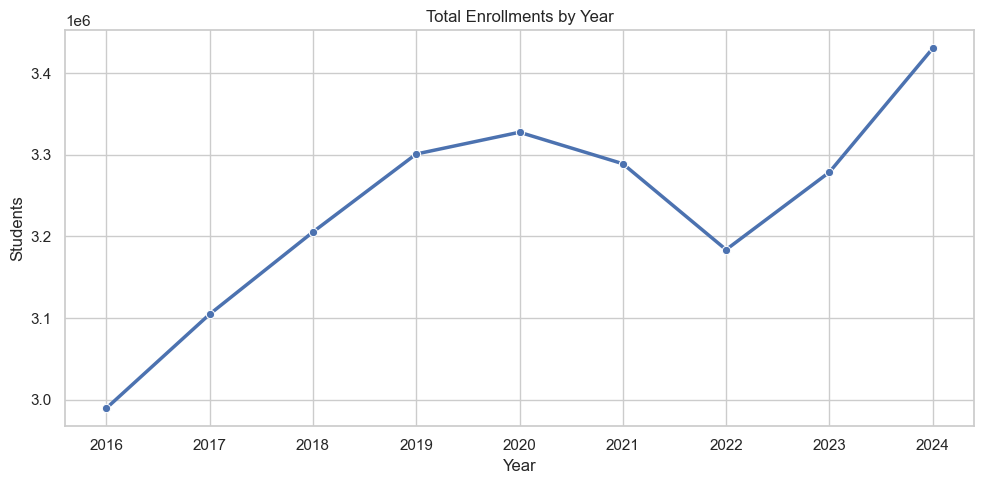

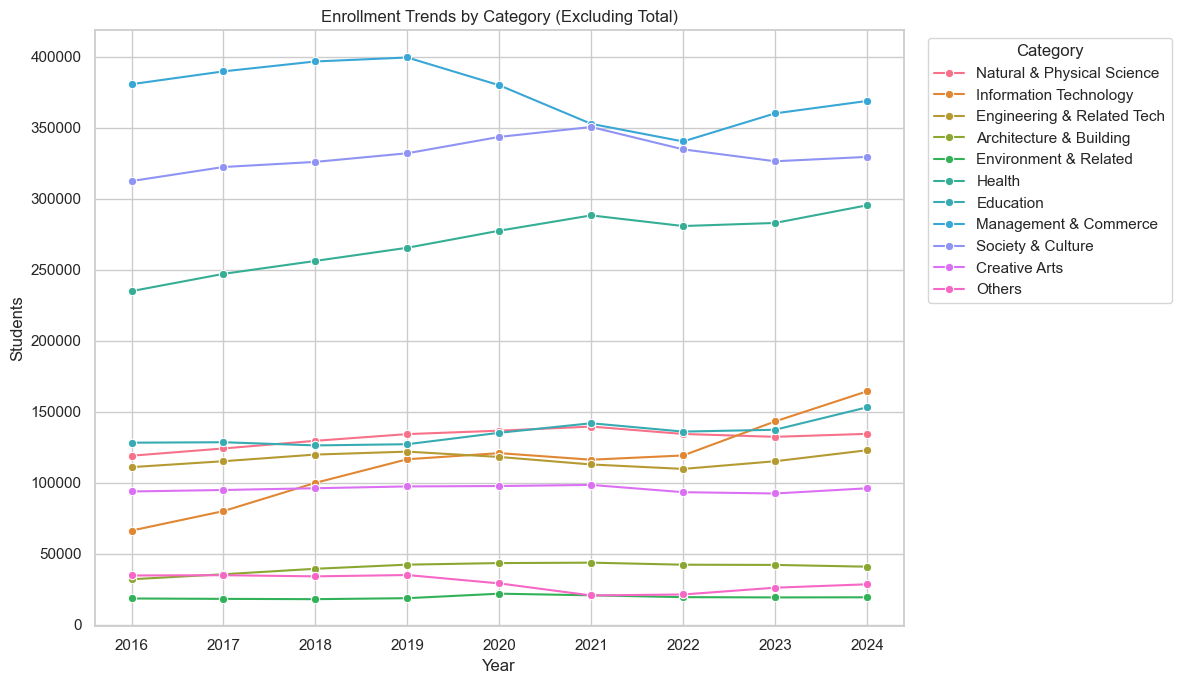

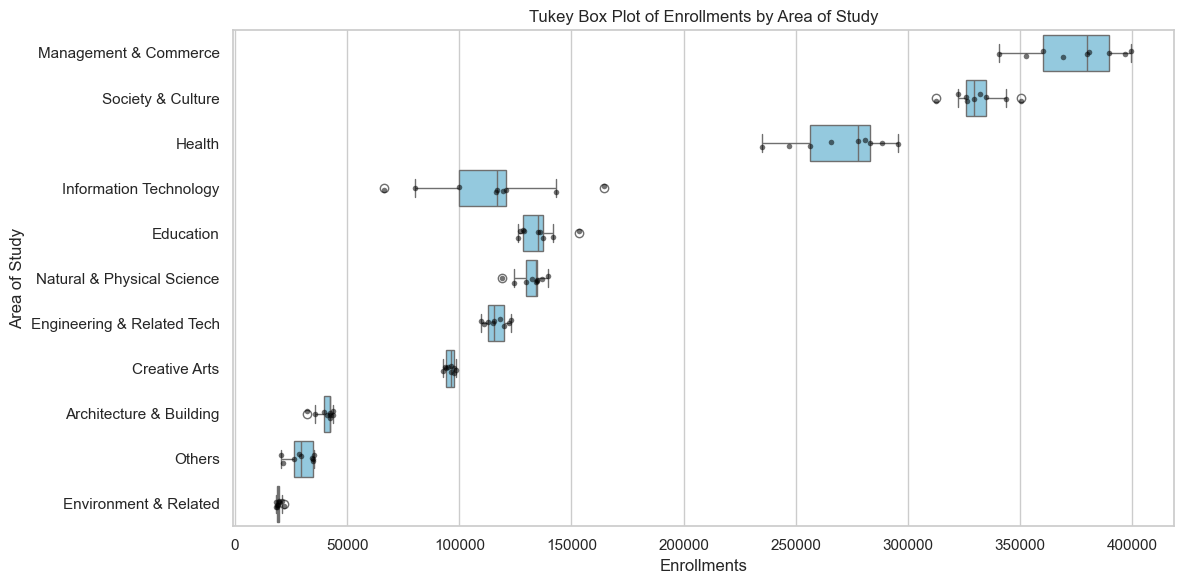

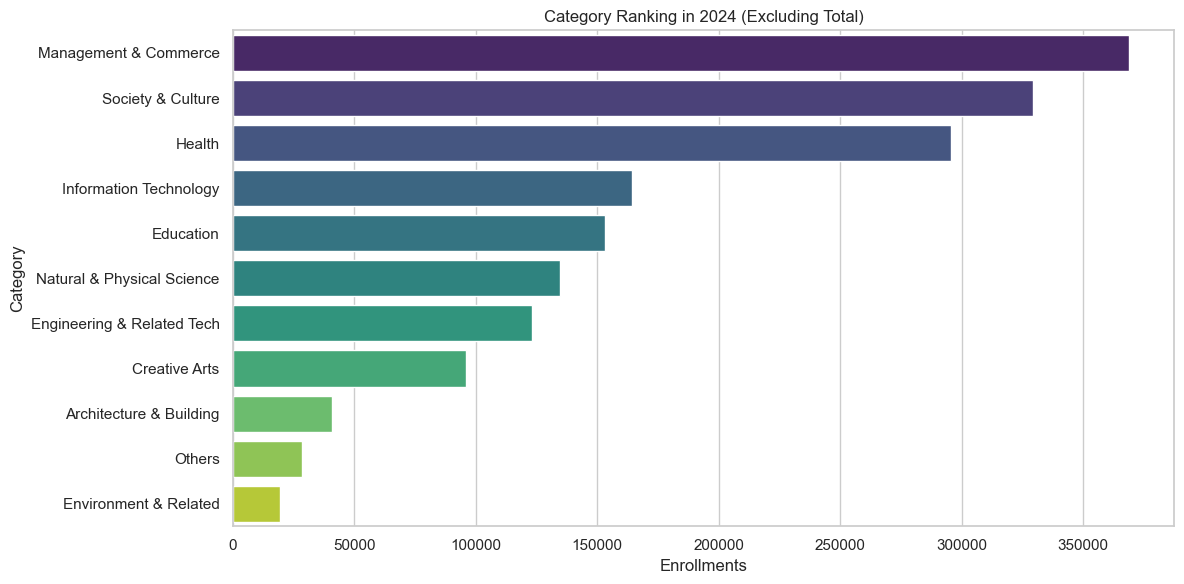

In [10]:
if year_cols:
    yearly_totals = enrollment_long.groupby("Year", as_index=False)["Enrollments"].sum()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=yearly_totals, x="Year", y="Enrollments", marker="o", linewidth=2.5)
    plt.title("Total Enrollments by Year")
    plt.ylabel("Students")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=enrollment_long_no_total, x="Year", y="Enrollments", hue="Category", marker="o")
    plt.title("Enrollment Trends by Category (Excluding Total)")
    plt.ylabel("Students")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    latest_year = max(year_cols, key=int)
    latest_ranking = df_clean_no_total[["Category", latest_year]].sort_values(latest_year, ascending=False)
    category_order = latest_ranking["Category"].tolist()

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=enrollment_long_no_total,
        x="Enrollments",
        y="Category",
        order=category_order,
        whis=1.5,
        color="skyblue",
    )
    sns.stripplot(
        data=enrollment_long_no_total,
        x="Enrollments",
        y="Category",
        order=category_order,
        color="black",
        alpha=0.55,
        size=4,
    )
    plt.title("Tukey Box Plot of Enrollments by Area of Study")
    plt.xlabel("Enrollments")
    plt.ylabel("Area of Study")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=latest_ranking, x=latest_year, y="Category", hue="Category", palette="viridis", legend=False)
    plt.title(f"Category Ranking in {latest_year} (Excluding Total)")
    plt.xlabel("Enrollments")
    plt.tight_layout()
    plt.show()
else:
    print("No year columns detected for trend visualizations.")

## 5. Explore Correlations Across Years

Check how yearly enrollment patterns move together across the time series.

In [ ]:
if len(year_cols) >= 2:
    corr_matrix = df_clean[year_cols].corr()
    display(corr_matrix)

    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Between Enrollment Years")
    plt.tight_layout()
    plt.show()
else:
    print("At least two year columns are needed to compute correlations.")

## 6. Identify Fast-Growing and Unusual Categories

Measure category growth from the first to the last year and flag unusually large changes.

In [ ]:
if "Category" in df_clean.columns and len(year_cols) >= 2:
    growth_df = df_clean_no_total[["Category", year_cols[0], year_cols[-1]]].copy()
    growth_df["Absolute Change"] = growth_df[year_cols[-1]] - growth_df[year_cols[0]]
    growth_df["Percent Change"] = (growth_df["Absolute Change"] / growth_df[year_cols[0]] * 100).round(2)

    q1 = growth_df["Absolute Change"].quantile(0.25)
    q3 = growth_df["Absolute Change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    growth_df["Potential Outlier"] = ~growth_df["Absolute Change"].between(lower, upper, inclusive="both")

    display(growth_df.sort_values("Absolute Change", ascending=False))

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=growth_df.sort_values("Absolute Change", ascending=False),
        x="Absolute Change",
        y="Category",
        hue="Category",
        palette="magma",
        legend=False,
    )
    plt.title(f"Change in Enrollments: {year_cols[0]} to {year_cols[-1]} (Excluding Total)")
    plt.tight_layout()
    plt.show()

    print(f"Outlier bounds for absolute change: lower={lower:.2f}, upper={upper:.2f}")
    display(growth_df[growth_df["Potential Outlier"]])
else:
    print("Category and at least two year columns are required for growth analysis.")

## 7. Separate Tukey Box Plots by Area of Study

This section shows one independent Tukey box plot for each area of study, using only that category's yearly enrollments.

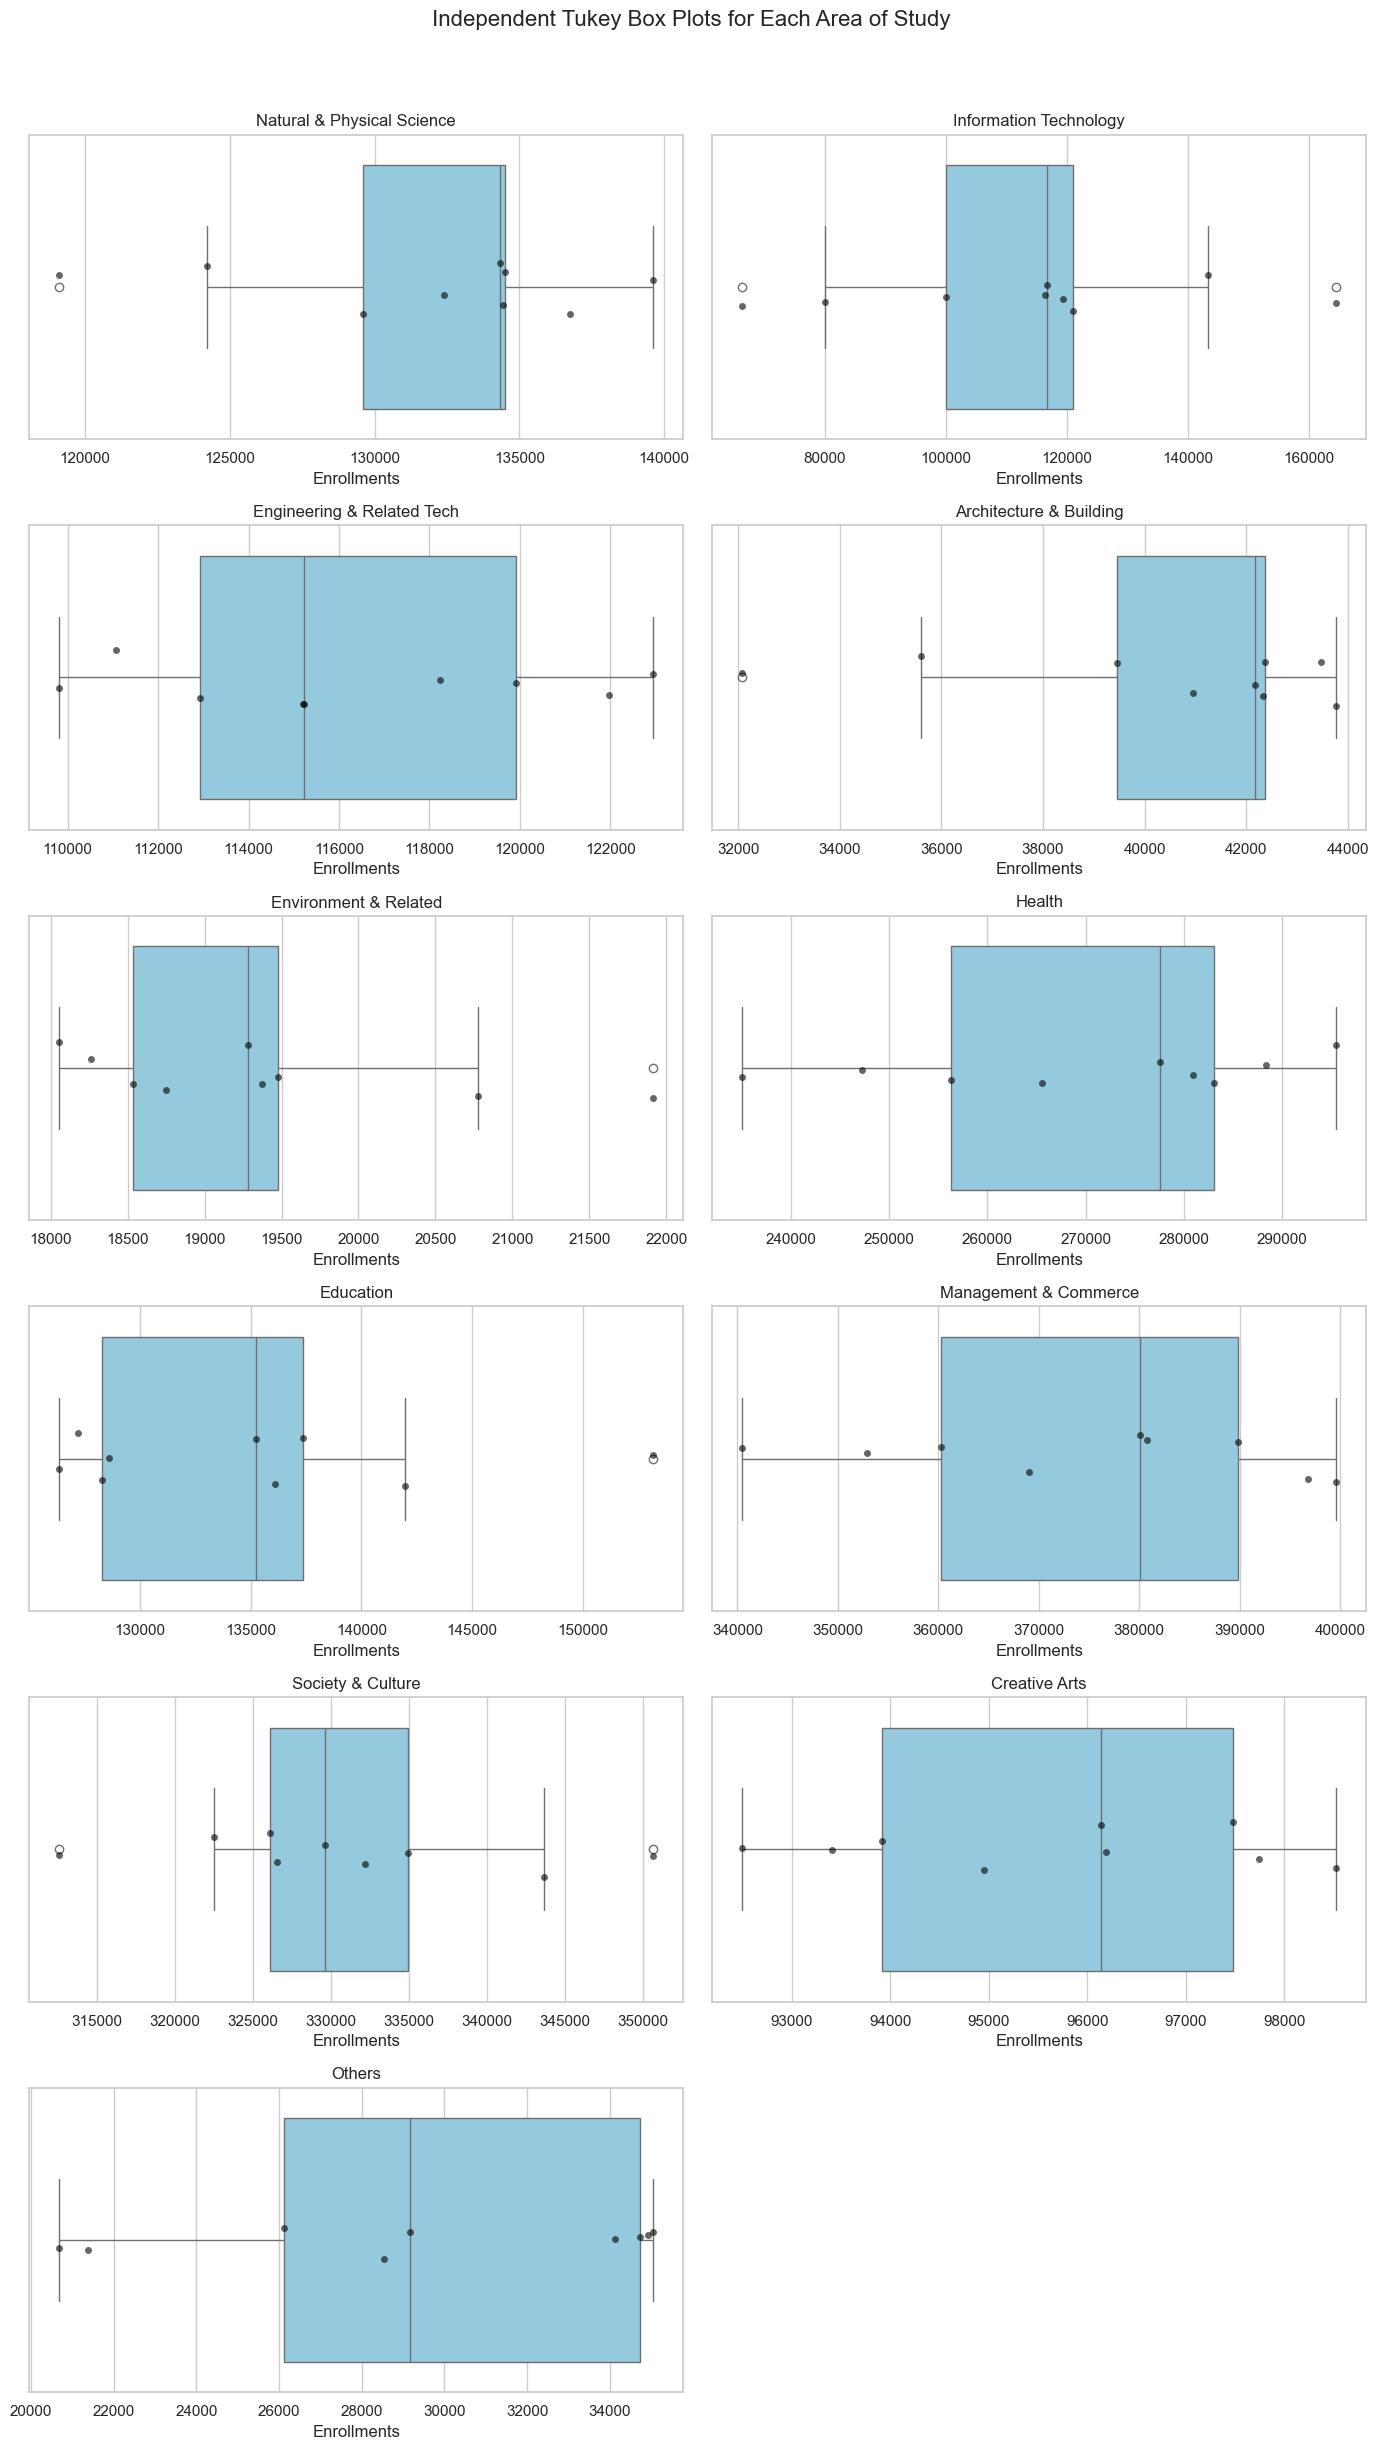

In [11]:
if "Category" in enrollment_long_no_total.columns:
    categories = enrollment_long_no_total["Category"].dropna().unique().tolist()
    n_cols = 2
    n_rows = (len(categories) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, category in zip(axes, categories):
        cat_values = enrollment_long_no_total.loc[
            enrollment_long_no_total["Category"] == category, "Enrollments"
        ].dropna()

        sns.boxplot(x=cat_values, ax=ax, whis=1.5, color="skyblue")
        sns.stripplot(x=cat_values, ax=ax, color="black", alpha=0.6, size=5)
        ax.set_title(category)
        ax.set_xlabel("Enrollments")
        ax.set_yticks([])

    for ax in axes[len(categories):]:
        ax.set_visible(False)

    plt.suptitle("Independent Tukey Box Plots for Each Area of Study", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Category data is required to create separate Tukey box plots.")